# IMPORT PART

In [27]:
import matplotlib.pyplot as plt
import torchvision.transforms as T
from torchvision.datasets import CIFAR10
from torch.utils.data import Dataset
import torchvision.transforms.functional as TF
import random


# LOAD CIFAR10
Benchmarking on CIFAR-10 to evaluate augmentation robustness

In [28]:
# Loading CIFAR-10 as a standard benchmark for evaluating augmentation robustness

train_raw = CIFAR10(
    root="./data",
    train=True,
    download=True )

100%|██████████| 170M/170M [00:52<00:00, 3.27MB/s] 


# EXPERIMENT 1 — Crop Only
**Baseline:**  Testing Spatial Invariance through basic cropping

In [29]:
transform_crop = T.Compose([
    # Forced focus on local features: Prevents the model from relying on object 
    # context by extracting sub-regions to learn 'Scale-Invariant' features.
    T.RandomResizedCrop(32, scale=(0.6, 1.0)), 
    
    # Gradient Stability: Normalizes intensities to [0, 1] and reorders 
    # dimensions to (C, H, W) for PyTorch's autograd engine compatibility.
    T.ToTensor()
])

# EXPERIMENT 2 — Crop + Flip
**Testing Reflection Invariance:** Common for natural images like CIFAR-10

In [30]:
transform_flip = T.Compose([
    # Scale Invariance: Extracts local patches to ensure the model recognizes 
    # objects regardless of their relative size or position in the frame.
    T.RandomResizedCrop(32, scale=(0.6, 1.0)),
    
    # Geometric Prior: Exploits horizontal symmetry to double dataset variety 
    # and teach 'Reflectional Invariance' for symmetric natural objects.
    T.RandomHorizontalFlip(), 
    
    # Tensor Cast: Normalizes pixel values for backpropagation stability and 
    # maps data to (C, H, W) for standard Deep Learning optimization.
    T.ToTensor()
])

# EXPERIMENT 3 — Crop + Flip + ColorJitter
**Color Invariance:** Forcing the model to rely on structural features/edges 
rather than specific color distributions.



In [31]:
transform_color = T.Compose([
    # Spatial Invariance: Forces the model to identify objects by localized 
    # structural features rather than global positioning.
    T.RandomResizedCrop(32, scale=(0.6, 1.0)),
    
    # Geometric Prior: Doubles effective training samples by utilizing 
    # horizontal symmetry found in natural image distributions.
    T.RandomHorizontalFlip(),
    
    # Photometric Invariance: Decouples identity from color histograms by jittering 
    # hues/brightness, preventing over-reliance on specific lighting conditions.
    T.ColorJitter(0.4, 0.4, 0.4, 0.1),
    
    # Floating Point Cast: Converts raw pixels to a [0, 1] range for gradient 
    # consistency and reshapes for PyTorch tensor processing.
    T.ToTensor()
])

# EXPERIMENT 4 — SimCLR Strong Augmentations
**SimCLR-inspired Strong Augmentations:** Implementing a high-strength noise 
pipeline **(Gaussian Blur + Grayscale)** to improve Contrastive Learning performance.

In [32]:
transform_blur = T.Compose([
    # Multi-Scale Learning: Forces the encoder to identify objects from local 
    # patches, promoting robust scale invariance.
    T.RandomResizedCrop(32, scale=(0.6, 1.0)),
    
    # Structural Prior: Exploits horizontal symmetry to improve generalization 
    # without altering semantic class integrity.
    T.RandomHorizontalFlip(),
    
    # Lighting Invariance: Shifts color distributions to ensure the model learns 
    # object identity rather than specific lighting or sensor characteristics.
    T.ColorJitter(0.4, 0.4, 0.4, 0.1),
    
    # Chromatic Ablation: Removes color cues to force the CNN to extract 
    # semantic shapes based purely on luminance and contrast.
    T.RandomGrayscale(p=0.2),
    
    # Low-Pass Filtering: Removes high-frequency noise and sharp edges to 
    # encourage the network to prioritize coarse, global structural features.
    T.GaussianBlur(kernel_size=3),
    
    # Optimization Format: Normalizes intensities to [0, 1] for gradient 
    # stability and converts to the required (C, H, W) tensor layout.
    T.ToTensor()
])

# EXPERIMENT 5 — Random Erasing


**Regularization via Information Dropping:** Random Erasing acts as a 
spatial dropout, forcing the network to learn from partial object occlusion.

In [33]:
transform_erase = T.Compose([
    # Multi-Scale Awareness: Encourages the model to learn from partial views 
    # of the object, improving detection at varying distances.
    T.RandomResizedCrop(32, scale=(0.6, 1.0)),
    
    # Mirror Symmetry: Enhances the dataset by leveraging the horizontal 
    # reflectional prior common in real-world visual data.
    T.RandomHorizontalFlip(),
    
    # Lighting Robustness: Shifts photometric properties to prevent the model 
    # from overfitting to specific color histograms or lighting environments.
    T.ColorJitter(0.4, 0.4, 0.4, 0.1),
    
    # Tensor Transformation: Normalizes pixels to [0.0, 1.0] and realigns 
    # memory for optimized GPU-based tensor operations.
    T.ToTensor(),
    
    # Structural Regularization: Simulates partial occlusion to force the 
    # network to learn redundant feature representations (e.g., paws vs. ears).
    T.RandomErasing(p=0.5)
])

# EXPERIMENT 6 — HYBRID
# SimCLR + Rotation Task


 Hybrid Baseline for downstream Equivariant Tasks

This pipeline creates a highly complex feature space to challenge the model's 
semantic consistency across severe distortions.

In [34]:
transform_hybrid = T.Compose([
    # Scale Invariance: Challenges the model to recognize semantic identity 
    # from varying sub-patches and localized spatial scales.
    T.RandomResizedCrop(32, scale=(0.6, 1.0)),
    
    # Mirror Symmetry: Leverages reflectional priors to expand the diversity 
    # of the feature space without losing class consistency.
    T.RandomHorizontalFlip(),
    
    # Photometric Jittering: Decouples object recognition from lighting 
    # conditions to prevent overfitting to specific color casts.
    T.ColorJitter(0.4, 0.4, 0.4, 0.1),
    
    # Chromatic Robustness: Encourages the network to prioritize structural 
    # geometry over color histograms (Prevents "cheating" by hue).
    T.RandomGrayscale(p=0.2),
    
    # Low-Pass Filtering: Removes high-frequency noise to focus the encoder 
    # on coarse, global structural semantics and object boundaries.
    T.GaussianBlur(kernel_size=3),
    
    # Tensor Optimization: Casts image to [0, 1] range and realigns dimensions 
    # to (C, H, W) for high-performance autograd processing.
    T.ToTensor()
])

# ROTATION FUNCTION
# (for Equivariant Learning Experiment)



**SELF-SUPERVISED PRETEXT TASK: ROTATION**
Implementing a 4-way classification task (0, 90, 180, 270) to encourage
the model to learn semantic orientation features (Equivariant Learning).

In [35]:
def rotate(img):
    """
    Applies a random discrete rotation to an image to create a labels-free 
    learning signal.
    """
    
    # Defining a discrete set of orthogonal angles (C_4 symmetry group).
    # This prevents interpolation artifacts that occur with arbitrary angles.
    angles = [0, 90, 180, 270]

    # Stochastically selecting a transformation 'class'
    angle = random.choice(angles)

    # Applying the geometric transformation via functional torchvision API.
    # TF.rotate handles PIL/Tensor inputs while maintaining semantic integrity.
    rotated_img = TF.rotate(img, angle)

    # Returning both the sample and its 'synthetic label' (the angle).
    # This allows for Equivariant Feature Learning during backpropagation.
    return rotated_img, angle

# VISUALIZATION FUNCTION


 Qualitative analysis of transformations to verify data distribution shifts.

In [36]:
def show_augmented_images(transform, title, n=6):
    """
    Renders a grid of stochastically transformed samples for visual inspection 
    of the data distribution shift.
    """
    
    # Initializing a subplot grid for a side-by-side comparative analysis
    fig, axes = plt.subplots(1, n, figsize=(14, 3))

    for i in range(n):
        # Stochastic sampling: Fetching a random instance from the raw dataset
        img, _ = train_raw[random.randint(0, len(train_raw)-1)]

        # Applying the experimental transformation pipeline
        img = transform(img)

        # Tensor Dimensionality Re-ordering:
        # PyTorch Tensors are (Channel, Height, Width) [C, H, W], 
        # but Matplotlib requires (Height, Width, Channel) [H, W, C].
        # .permute(1, 2, 0) is used to realign the axes for correct RGB rendering.
        axes[i].imshow(img.permute(1, 2, 0))
        
        # Eliminating coordinate axes to focus purely on visual feature artifacts
        axes[i].axis("off")

    # Super-titling the figure for experimental documentation and reporting
    plt.suptitle(title, fontsize=14)

    # Rendering the finalized qualitative plot
    plt.show()

# ROTATION VISUALIZATION

In [37]:
def show_rotation_images(n=6):
    """
    Renders a series of rotated samples with their corresponding synthetic 
    classification labels (the rotation angles).
    """
    
    # Constructing a visualization grid for qualitative assessment of orientation
    fig, axes = plt.subplots(1, n, figsize=(14, 3))

    for i in range(n):
        # Sampling a raw data point from the CIFAR-10 distribution
        img, _ = train_raw[random.randint(0, len(train_raw)-1)]

        # Generating a (transformed_sample, synthetic_label) pair.
        # Here, 'angle' serves as the supervised target for the pretext task.
        rotated_img, angle = rotate(img)

        # On-the-fly normalization to Tensor format for standard display pipeline
        rotated_img = T.ToTensor()(rotated_img)

        # Re-aligning axes from (C, H, W) to (H, W, C) for Matplotlib rendering
        axes[i].imshow(rotated_img.permute(1, 2, 0))

        # Annotating each sample with its ground-truth 'Pretext Label'
        axes[i].set_title(f"{angle}°")

        # Removing visual noise (axes) to highlight the object's orientation
        axes[i].axis("off")

    # The title reflects the core objective: Equivariant Representation Learning.
    # We want the model's internal features to change 'predictably' as the input rotates.
    plt.suptitle(
        "Rotation Task (Self-Supervised Equivariant Learning)",
        fontsize=14
    )

    # Executing the final rendering
    plt.show()

# CUSTOM DATASET WRAPPER WITH OFFLINE CACHING

This class implements a 'Cache-on-Init' strategy. By pre-calculating 
augmentations, we move the computational load from the training loop (GPU-wait)
to the initialization phase (CPU-heavy), significantly increasing throughput.

In [38]:
class AugmentedDataset(Dataset):
    """
    A custom Dataset decorator that applies and stores transformations in memory 
    to optimize training performance.
    """

    def __init__(self, dataset, transform):
        # Storing references to the base dataset and the transformation pipeline
        self.dataset = dataset
        self.transform = transform
        
        # Initializing an in-memory buffer for high-speed data retrieval
        self.cached_data = []

        # DATA PRE-PROCESSING LOOP:
        # Applying the static/stochastic transformations once during object creation.
        # This prevents the 'CPU Bottleneck' where the GPU stays idle while 
        # waiting for the CPU to augment images during each epoch.
        for i in range(len(dataset)):
            # Extracting raw sample and its ground-truth label
            img, label = dataset[i]
            
            # Mapping the PIL Image to the augmented Tensor feature space
            img = self.transform(img)
            
            # Caching the (Tensor, Label) pair into RAM for O(1) access time
            self.cached_data.append((img, label))

    def __len__(self):
        """
        Returns the cardinality of the augmented dataset for the DataLoader's 
        batching logic.
        """
        return len(self.cached_data)

    def __getitem__(self, idx):
        """
        Provides direct memory-access to the pre-augmented samples.
        Essential for achieving maximum I/O speed during the training phase.
        """
        return self.cached_data[idx]

# EXPERIMENT 1


BASELINE EVALUATION (SPATIAL INVARIANCE)

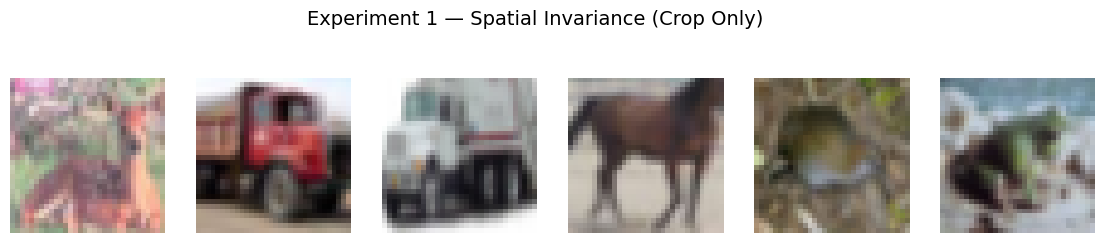

In [39]:
# Initializing the specialized dataset instance for the first ablation study.
# Here, we test the model's capacity to learn from localized spatial features 
# without any additional noise (flips or color shifts).
train_crop_ds = AugmentedDataset(
    train_raw,
    transform_crop
)

# QUALITATIVE SANITY CHECK:
# Invoking the visualization suite to confirm that the 'RandomResizedCrop' 
# preserves enough semantic information for the class to remain identifiable.
# This acts as a visual 'Ground Truth' verification before starting the training.
show_augmented_images(
    transform_crop,
    "Experiment 1 — Spatial Invariance (Crop Only)"
)

# EXPERIMENT 2

REFLECTIONAL INVARIANCE STUDY


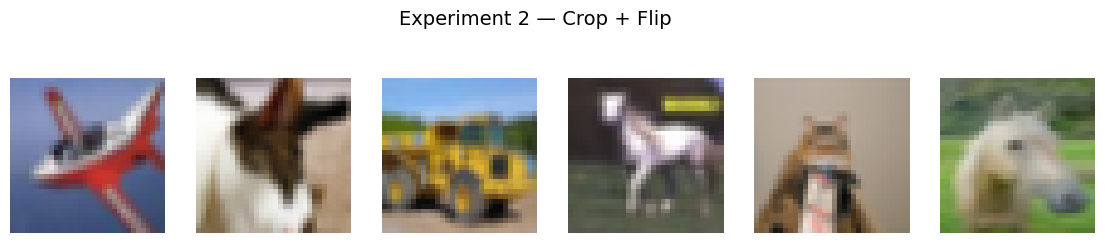

In [40]:
# Instantiating the second experimental condition. 
# By adding horizontal flips, we are effectively teaching the model that semantic 
# identity is invariant to left-right reflections—a key prior for natural images.
train_flip_ds = AugmentedDataset(
    train_raw,
    transform_flip
)

# QUALITATIVE COMPARISON:
# Visualizing the interaction between stochastic cropping and flipping. 
# This helps ensure that the 'Reflectional Invariance' doesn't distort the 
# structural features needed for classification (e.g., ensuring a 'car' flipped 
# horizontally is still clearly a 'car').
show_augmented_images(
    transform_flip,
    "Experiment 2 — Crop + Flip"
)


# EXPERIMENT 3

PHOTOMETRIC INVARIANCE (COLOR ROBUSTNESS)



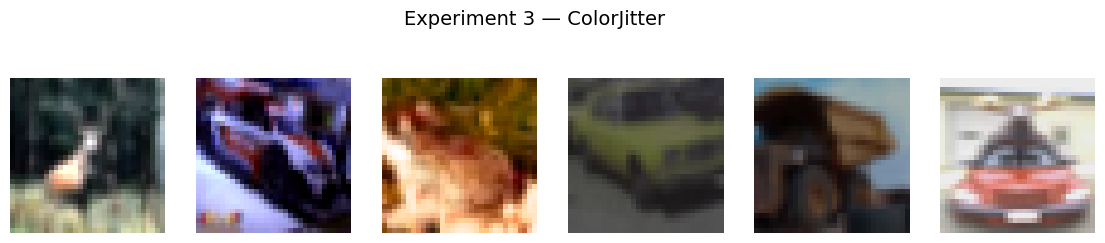

In [41]:
# Instantiating the third experimental setup to test the impact of color shifts.
# By jittering brightness, contrast, and saturation, we evaluate how the model 
# generalizes across different lighting conditions and sensor noise.
train_color_ds = AugmentedDataset(
    train_raw,
    transform_color
)

# CROSS-MODAL VISUALIZATION:
# This step is crucial to ensure that the jittering parameters (0.4) are 
# aggressive enough to challenge the model, yet conservative enough to 
# prevent 'Semantic Drift'—where the object becomes unrecognizable to the human eye.
show_augmented_images(
    transform_color,
    "Experiment 3 — ColorJitter"
)


# EXPERIMENT 4

SIMCLR-INSPIRED COMPOSITE AUGMENTATIONS


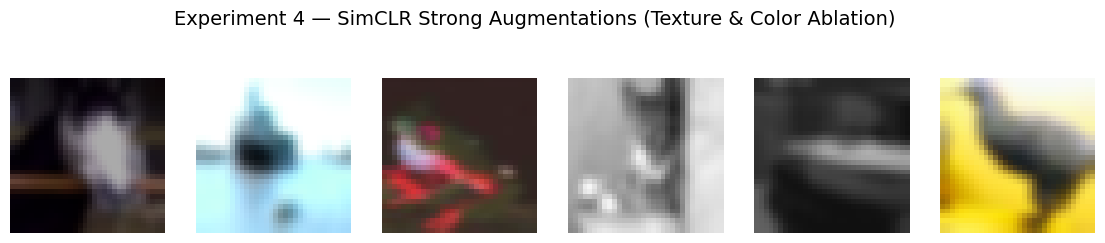

In [42]:
# Constructing a high-entropy data pipeline to simulate Contrastive Learning settings.
# Here, we introduce 'Gaussian Blur' and 'Grayscale' to force the encoder 
# to learn structural/spatial dependencies while ignoring texture and color cues.
train_blur_ds = AugmentedDataset(
    train_raw,
    transform_blur
)

# STRESS-TEST VISUALIZATION:
# This qualitative check confirms if the 'Low-Pass Filter' (Blur) and 
# 'Chromatic Information Removal' (Grayscale) allow for enough global structure 
# to remain. In research, this is critical for learning 'High-Level Semantics'.
show_augmented_images(
    transform_blur,
    "Experiment 4 — SimCLR Strong Augmentations (Texture & Color Ablation)"
)


# SIMCLR POSITIVE PAIR GENERATION & VISUALIZATION

This utility demonstrates the core mechanism of Contrastive Learning:
Mapping two distinct 'stochastic views' of the same instance to the same identity

In [43]:
def show_simclr_positive_pairs(dataset, transform, n_images=2):
    """
    Visualizes the multi-view data generation strategy.
    Encourages the model to learn 'Invariance' by maximizing agreement 
    between differently augmented versions of the same source image.
    """

    # Initializing a grid: (Source | View A | View B)
    fig, axes = plt.subplots(
        n_images, 
        3, 
        figsize=(9, 3 * n_images)
    )

    for i in range(n_images):
        # LATENT SOURCE SAMPLING:
        # Fetching an un-augmented sample from the raw data distribution.
        img, _ = dataset[random.randint(0, len(dataset)-1)]

        # STOCHASTIC DATA PIPELINE:
        # Applying the SAME transformation pipeline twice. 
        # Due to random parameters (crop/color/flip), this creates two 
        # structurally different but semantically identical representations.
        view1 = transform(img)
        view2 = transform(img)

        # Rendering the Reference Image
        axes[i,0].imshow(img)
        axes[i,0].set_title("Original Source")

        # Rendering View 1: Focused on specific spatial/chromatic features
        # .clip(0,1) ensures numerical stability for matplotlib rendering
        axes[i,1].imshow(
            view1.permute(1,2,0).clip(0,1)
        )
        axes[i,1].set_title("Augmented View A")

        # Rendering View 2: A secondary high-entropy perspective
        axes[i,2].imshow(
            view2.permute(1,2,0).clip(0,1)
        )
        axes[i,2].set_title("Augmented View B")

        # Removing redundant axes to emphasize the visual contrast
        for j in range(3):
            axes[i,j].axis("off")

    # The title highlights the Contrastive Learning objective.
    plt.suptitle(
        "SimCLR Pretext Task: Maximizing Agreement between Positive Pairs",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

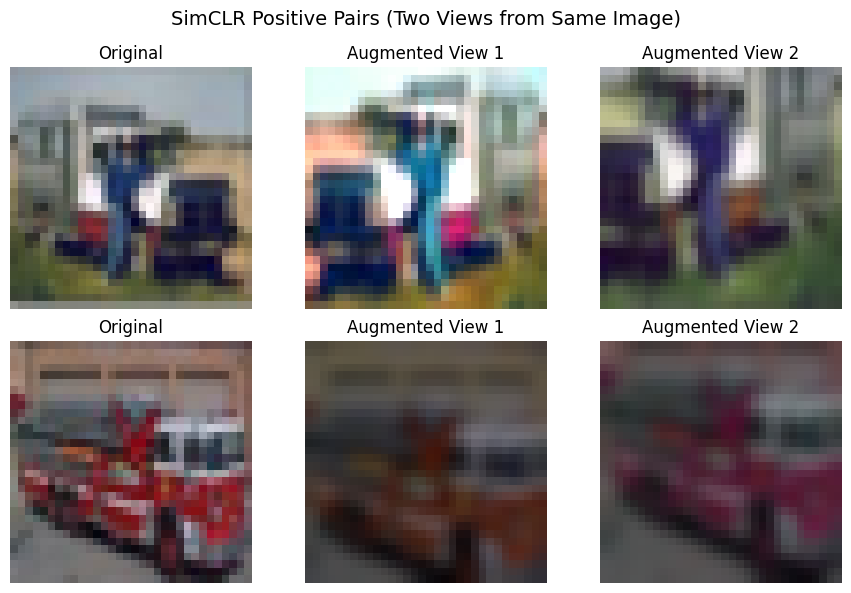

In [45]:
show_simclr_positive_pairs(
    train_raw,
    transform_blur
)

# EXPERIMENT 5

SPATIAL OCCLUSION & STRUCTURAL REGULARIZATION

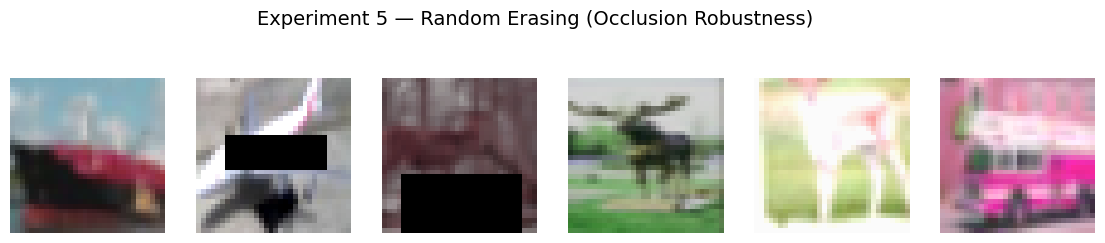

In [46]:
# Implementing 'Random Erasing' as a sophisticated form of input-space Dropout.
# This forces the network to become robust against partial occlusions, ensuring 
# it doesn't converge on a single 'Shortcut' feature for classification.
train_erase_ds = AugmentedDataset(
    train_raw,
    transform_erase
)

# ROBUSTNESS VALIDATION:
# Evaluating the diversity of erased regions. In a research context, we use 
# this to verify that the 'Information Dropping' isn't so severe that it 
# obliterates all discriminative features, which would lead to 'Underfitting'.
show_augmented_images(
    transform_erase,
    "Experiment 5 — Random Erasing (Occlusion Robustness)"
)

# EXPERIMENT 6
# HYBRID (SimCLR + Rotation)


HYBRID AGGREGATION & MULTI-VIEW REPRESENTATION

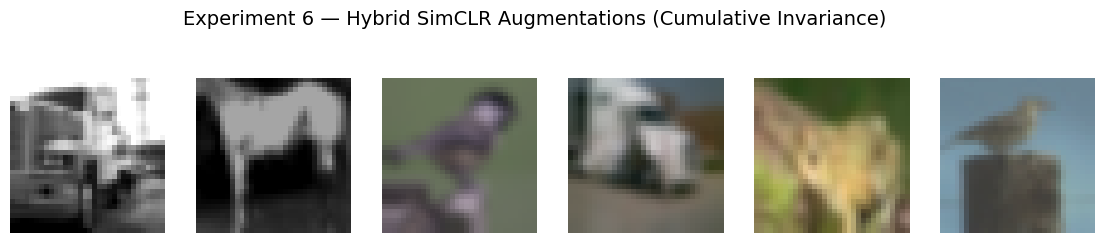

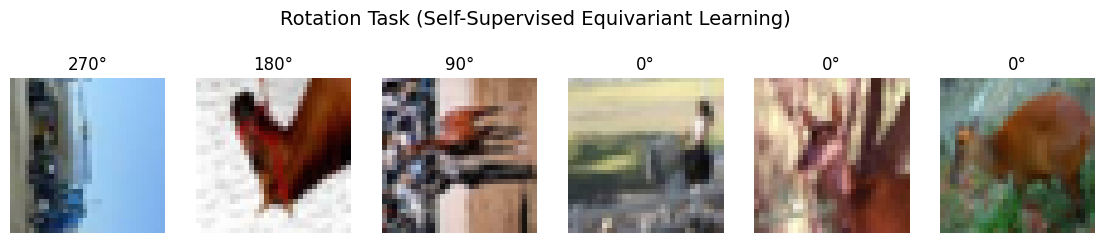

In [47]:
# Integrating all previous augmentations into a unified stochastic pipeline.
# In Self-Supervised Learning (SSL), this 'Hybrid' approach is designed to 
# generate two highly distorted views of the same image, forcing the encoder 
# to map them to a similar point in the Latent Space (Invariance Learning).
train_hybrid_ds = AugmentedDataset(
    train_raw,
    transform_hybrid
)

# FINAL STRESS-TEST:
# Visualizing the cumulative effect of spatial, photometric, and noise-based 
# augmentations. We verify that the 'Semantic Core' of the object remains 
# persistent despite the high degree of synthetic variance introduced.
show_augmented_images(
    transform_hybrid, 
    "Experiment 6 — Hybrid SimCLR Augmentations (Cumulative Invariance)"
)


# PRETEXT TASK VALIDATION: ROTATION EQUIVARIANCE

# Executing the Equivariant Learning visualization. This confirms that the 
# model has a reliable supervised signal for orientation-aware features.
# Understanding 'Rotation' acts as a proxy for understanding object parts 
# and their relative geometric relationships.
show_rotation_images()